[colab에서 실행하기](https://colab.research.google.com/github/science-odysseia/AILearning/blob/main/AI_15.ipynb)

코랩에서 실행할 경우

아래 코드를 한 번 실행만 시켜 주시고 다음으로 넘어가 주세요.

In [7]:
import os, cv2, matplotlib.pyplot as plt

if "AILearning" not in os.getcwd():
    !git clone https://github.com/science-odysseia/AILearning.git
    os.chdir("/content/AILearning")
try:
    # 코랩 환경 시도
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(img):
        import cv2
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

# 추적 알고리즘

## 1. 템플릿 매칭(Template Matching)

원본 이미지에서 목표 이미지를 찾는 매칭.

원본 이미지에서 찾는 목표 이미지의 크기를 **`거의 정확하게 맞춰 주어야`** 하며,

목표 이미지가 원본 상에서 만약 회전이나 크기가 너무 커지거나 작아지면 찾지 못하는 문제가 발생한다.

반드시 원본과 목표이미지 모두 `흑백이미지`를 사용해야 한다.

사용 명령어 : `cv2.matchTemplate(원본이미지, 목표이미지, 방식)`

원본 이미지에서 목표 이미지의 조정된 크기의 창틀을 움직여가며 가장 잘 맞는 지점을 찾는 방식을 사용한다.

가령 600 x 600 이미지에서 목표 이미지가 50 x 100 으로 있다고 가정했을 때

600 x 600 이미지에서 50 x 100 크기의 창틀을 움직여가면서 목표 이미지와 맞는지 비교해가는 방식인 것이다.

원본, 목표 이미지

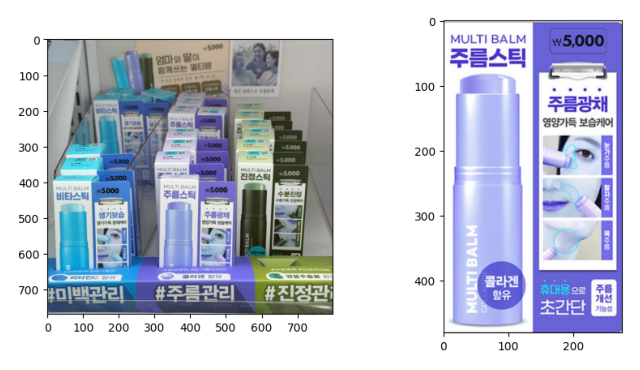

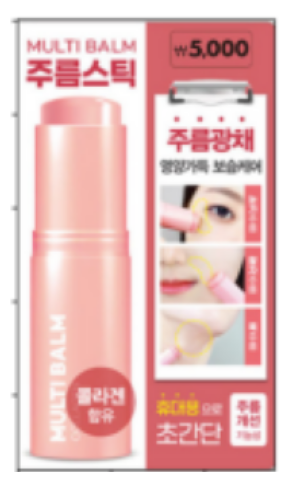

(433, 765, 3) (342, 199, 3)


In [3]:
img, target = cv2.imread(r'imgs_CV04/beau_3.png'), cv2.imread(r'imgs_CV04/new_target.png')
cv2_imshow(img)
cv2_imshow(target)
print(img.shape, target.shape)

원본, 목표이미지 흑백변환

In [4]:
image_gray, target_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)

목표이미지 크기변환(원본상의 목표에 맞게)

In [5]:
target_gray_resized = cv2.resize(target_gray, (200, 400))

Template Matching 연산

`cv2.matchTemplate(원본이미지_흑백, 사이즈 조정된 목표이미지_흑백, 계산방식)`

In [6]:
result = cv2.matchTemplate(image_gray, target_gray_resized, cv2.TM_CCOEFF_NORMED)

결과값 및 위치 확인

In [7]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

```python
min_val, min_loc
```
가장 안 맞는 위치의 값과 위치(직사각형의 왼쪽 위 꼭지점 위치)

```python
max_val, max_loc
```
가장 잘 맞는 위치의 값과 위치(직사각형의 왼쪽 위 꼭지점 위치)

결과 표시

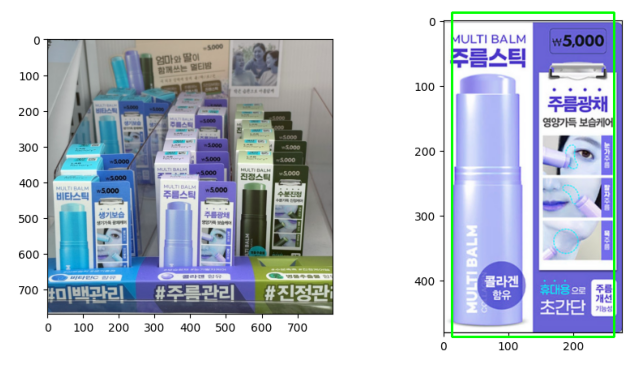

In [8]:
img_result = cv2.rectangle(img, max_loc, (max_loc[0] + 200, max_loc[1] + 400), (0, 255, 0), 2)
cv2_imshow(img_result)

## 2. 배경제거

원본 동영상

In [3]:
# Colab에서 실행할 경우 에러가 발생합니다. 반드시 로컬에서 실행하세요.

path ='imgs_CV04/newyork.mp4'
cap = cv2.VideoCapture(path)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    cv2.imshow('', frame)
    
    if cv2.waitKey(10) == ord('q'):
        break

cap.release()               
cv2.destroyAllWindows()     
    

QFontDatabase: Cannot find font directory /home/scienceodysseia/py_work/my_first_venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/scienceodysseia/py_work/my_first_venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/scienceodysseia/py_work/my_first_venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/scienceodysseia/py_work/my_first_venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to 

학습기 생성

In [4]:
fgbg = cv2.createBackgroundSubtractorMOG2()

MOG2란?
- MOG(mixture of gaussians2)
- 각 pixel 색상변화를 가우시안 분포(정규분포) 모델링
- 배경(background: bg) 고정되어 있거나 오래 머무는 색상 >> 배경 학습
- 전경(foreground: fg): 갑자기 툭 나타난 색상 : 움직이는 물체로 판단
- 가우시안 혼합모델을 활용

학습기 적용한 동영상 코드

In [5]:
# Colab에서 실행할 경우 에러가 발생합니다. 반드시 로컬에서 실행하세요.

path ='imgs_CV04/newyork.mp4'
cap = cv2.VideoCapture(path)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    fgmask = fgbg.apply(frame)
    cv2.imshow('', fgmask)
    
    if cv2.waitKey(10) == ord('q'):
        break

cap.release()               
cv2.destroyAllWindows()  

`fgbg = cv2.createBackgroundSubtractorMOG2()`를 통해 

각 픽셀의 이력을 학습하는 학습기 객체를 생성한 후,

`fgmask = fgbg.apply(frame)`를 통해 `frame` 이미지를 객체에 적용하여 

배경(가만히 있는 요소)을 지우고, **움직이는 점들(전경 객체)** 만 흰색으로 추출한 마스크를 생성한다.

첫 이미지 `frame`이 들어오면 `fgmask`는 아직 비교 대상이 없으므로 전체 흰색 또는 전체 검정색이 나온다.

이후 두 번째 이미지 `frame`이 들어오면 `fgmask`는 이전 이미지와 비교하여 

조금이라도 변한 부분의 픽셀을 흰색으로 설정한다.

이후 n 번째 이미지 `frame`이 들어오면 이전 이미지들을 포함하여 통계를 내서 각 픽셀별로 

배경인지, 움직이는 물체인지 파악한다.

위 코드는 흑백인 `fgmask`를 띄우는 영상 코드이고,

이를 원본 영상에 적용해 컬러로 띄우고 싶으면 아래 코드처럼 `and`연산으로 mask를 적용시키면 된다.

In [ ]:
# Colab에서 실행할 경우 에러가 발생합니다. 반드시 로컬에서 실행하세요.

path ='imgs_CV04/newyork.mp4'
cap = cv2.VideoCapture(path)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    res = cv2.bitwise_and(frame, frame, mask = fgbg.apply(frame)) # and 연산 적용부분.
    cv2.imshow('', res)
    
    if cv2.waitKey(10) == ord('q'):
        break

cap.release()               
cv2.destroyAllWindows()  

## 3. MeanShift

#### MeanShift 전체 코드

In [6]:
import numpy as np
import cv2

# 1. 초기 설정 및 종료 기준 정의
x, y, w, h = 1150, 400, 100, 100  # 추적 대상 초기 위치
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

cap = cv2.VideoCapture(r'imgs_CV04/newyork.mp4')

# 2. 첫 프레임에서 추적 대상(ROI)의 색상 히스토그램 학습
ret, frame = cap.read()
roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# H(색상) 채널 히스토그램 계산 및 0~255 정규화
roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# 3. 비디오 루프 돌며 실시간 추적
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # [핵심 1] 역투영: 현재 프레임에서 학습한 색상이 나타날 확률 지도(dst) 생성
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    # [핵심 2] MeanShift: 확률 지도 내에서 무게중심을 찾아 박스 위치(x, y, w, h) 갱신
    ret, (x, y, w, h) = cv2.meanShift(dst, (x, y, w, h), termination)

    # 결과 그리기 및 출력
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.imshow('MeanShift Tracking', frame)
    
    if cv2.waitKey(30) == ord('q'): break

cap.release()
cv2.destroyAllWindows()

![MeanShift](imgs_CV04/MeanShift.png)

#### 추적 대상 초기 위치 설정

In [ ]:
x, y, w, h = 1150, 400, 100, 100 

추적할 대상을 맨 처음 이미지에서 사각형으로 테두리화하기위한 좌표를 설정하는 코드이다.

(1150, 400), (1150 + 100, 400), (1150, 400 + 100), (1150 + 100, 400 + 100)을 꼭지점으로 하는 사각형을 잡는 것이다.

#### 종료 조건 설정

In [ ]:
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

Meanshift의 종료 조건 코드이다.

(종료 조건 스위치, 반복 횟수, 오차) 구조로,

반복 횟수까지만 연산을 하게 하고, 그리고 움직인 픽셀 길이가 오차 미만으로 나오면 연산을 중단시키는 종료조건이 되겠다.

|상수이름|정수값|이진수|의미|
|:---:|:---:|:---:|:---:|
|`cv2.TERM_CRITERIA_COUNT`|1|01|지정된 반복 횟수에 도달하면 멈춰라.|
|`cv2.TERM_CRITERIA_EPS`|2|10|목표 수치가 지정된 오차(정밀도)보다 작아지면 멈춰라.|
|`cv2.TERM_CRITERIA_MAX_ITER`|1|01|COUNT와 완전히 동일한 값(이름만 다름)|

#### 첫 프레임 정보 학습

In [ ]:
ret, frame = cap.read()
roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# H(색상) 채널 히스토그램 계산 및 0~255 정규화
roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

`ret, frame = cap.read()` : 첫 프레임 이미지 데이터 받아오기

`roi = frame[y:y+h, x:x+w]` : 이미지 배열에서 추적 객체의 직사각형 부분만 따오기(ROI : Region Of Interest, 관심영역)

`roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)` : ROI 영역 이미지를 BGR에서 HSV로 변환

`roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])`: roi_hsv 이미지의 색상 히스토그램

`[roi_hsv]` : 이미지들의 배열. 지금처럼 단일 이미지만 넣어도 되지만, 여러 이미지를 넣어 연산할 수도 있음.

`[0]` : 사용할 채널(0채널). 여기서는 HSV의 0채널, 즉 H(Hue, 색상) 값만 사용하겠다는 뜻.

`None` : 마스크. 특정 부분만 잘라서 그 부분만 계산하고 싶을 때 사용한다. 여기서는 이미 roi로 영역을 자르고 시작했기 때문에 사용하지 않음.

`[180]` : HSV는 0 - 179까지의 색상이 있는데, 이를 180개의 구역으로 나눈다는 뜻. 즉 모든 색에 대해 전부 찾겠다는 의미.

`[0, 180]` : 범위를 0 - 180으로 설정하겠다는 뜻. 즉 버리는 색상 없이 전부 찾겠다는 뜻.

`cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)` : 

`roi_hist`의 구성요소 값들을 `cv2.NORM_MINMAX` 방식에 따라 최솟값 0, 최댓값 255로 재조정하겠다는 의미.

`cv2.normalize(roi_hist, roi_hist, target_min, target_max, cv2.NORM_MINMAX)`의 방식을 적용하여 변환되는 픽셀값의 공식은 아래와 같다.

$$
P_{new} = \frac{P - \mathrm{min}}{\mathrm{max} - \mathrm{min}} \times (\mathrm{target\_max} - \mathrm{target\_min}) + \mathrm{target\_min}
$$

($\mathrm{max}, \mathrm{min}$ : `roi_hist`의 각 픽셀값 중 가장 큰 값, 가장 작은 값)

여기서는 $\mathrm{target\_min} = 0, \mathrm{target\_max} = 255$ 이므로

$$P_{new} = \frac{P - \mathrm{min}}{\mathrm{max} - \mathrm{min}} \times 255 $$

#### 이후 이미지들에 적용

In [ ]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

반복문. 영상이미지가 받아지면 이미지를 읽고, 실패하면 중단하는 코드.

#### HSV 변환

In [ ]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

#### 역투영(Back Projection) 이미지 생성

In [ ]:
dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

`cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)`

`[hsv]` : hsv 이미지를 사용하겠다.

`[0]` : 0번 채널(Hue값)만 사용하겠다.

`roi_hist` : 비교할 기준.

`[0, 180]` : 0 - 180 범위에서 계산하겠다.

`1` : 결과 이미지 배열에 곱해줄 계수. 1보다 큰 값을 쓰면 더 밝아지고, 1보다 작은 값을 쓰면 어두워진다.

#### MeanShift 연산 코드

In [ ]:
ret, (x, y, w, h) = cv2.meanShift(dst, (x, y, w, h), termination)

`ret, result = cv2.meanShift(dst, start, termination)`

`ret` : 목표지점을 찾기 위해 반복한 횟수

`result` : 찾은 목표위치

(x, y, w, h) 형태로 리턴되며, 왼쪽 위 점이 (x, y)이고, 오른쪽 아래 점이 (x + w, y + h)인 직사각형이란 뜻이다.

`dst` : 역투영 이미지 'dst'를 사용하겠다.

`start` : 이 위치에서 직사각형을 출발시키겠다. 마찬가지로 왼쪽 위 점이 (x, y)이고, 오른쪽 아래 점이 (x + w, y + h)인 직사각형이란 뜻이다.

`termination` : 종료 조건

(종료 조건 스위치, 반복 횟수, 오차) 구조로,

반복 횟수까지만 연산을 하게 하고, 그리고 움직인 픽셀 길이가 오차 미만으로 나오면 연산을 중단시키는 종료조건이 되겠다.

#### MeanShift 연산과정

MeanShift는 기본적으로 ROI(관심영역)내의 무게중심점을 따라 ROI의 중심을 옮겨가는 과정이다.

무게중심점을 구하는 공식은 아래와 같다.

$$
\bar{x} = \frac{\displaystyle \sum_{y} \sum_{x} x \cdot P(x, y)}{\displaystyle \sum_{y} \sum_{x} P(x, y)}
$$ 

$$
\bar{y} = \frac{\displaystyle \sum_{x} \sum_{y} y \cdot P(x, y)}{\displaystyle \sum_{x} \sum_{y} P(x, y)}
$$

#### 결과 직사각형 표시

In [ ]:
cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
cv2.imshow('MeanShift Tracking', frame)

#### 재생 속도 및 영상 종료 조건

In [ ]:
if cv2.waitKey(30) == ord('q'): break

`30ms`마다 `q`키 입력이 감지되면 영상 종료.

아래 코드는 MeanShift 알고리즘을 재생 없이 

아무 키를 누르면 다음 이미지로 넘어가서 과정을 차근차근 보여주는 코드이다.

In [ ]:
import numpy as np
import cv2

# 1. 초기 설정 및 비디오 로드
x, y, w, h = 1150, 400, 100, 100  # ROI 초기값 (실행 환경에 맞춰 설정)
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
cap = cv2.VideoCapture(r'imgs_CV04/newyork.mp4')

# 2. 첫 프레임 학습
ret, frame = cap.read()
if not ret:
    print("비디오를 읽을 수 없습니다.")
    cap.release()
    exit()

roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# 3. 비디오 처리 루프
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    img_draw = frame.copy() # 결과 출력용 복사본
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # [핵심] 역투영 확률 지도 생성
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    # [핵심] MeanShift 추적 실행
    ret_ms, (x, y, w, h) = cv2.meanShift(dst, (x, y, w, h), termination)

    # 화면 표시를 위한 시각화
    cv2.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # 여러 창 띄우기
    cv2.imshow('1. Original Frame', frame)       # 원본 영상
    cv2.imshow('2. Back-Projection (dst)', dst)  # 흑백 확률 지도
    cv2.imshow('3. Tracking Result', img_draw)   # 박스 그려진 결과

    # --- 사용자 요청 부분 ---
    # waitKey(0)은 키 입력이 있을 때까지 무한 대기합니다.
    key = cv2.waitKey(0) & 0xFF 
    if key == ord('q'): # 'q' 키를 누르면 루프 탈출
        break

cap.release()
cv2.destroyAllWindows()

--- 분석 모드 시작 ---
아무 키나 누르면 다음 프레임으로 이동합니다. 'q'를 누르면 종료합니다.


## 4. CamShift

![CamShift](imgs_CV04/CamShift.png)

CamShift는 MeanShift와 기본적으로 동일한 방식이다.

다만 차이점은

MeanShift의 경우 추적 대상 물체의 크기가 커져가거나 작아져가거나 혹은 회전 등을 하게 되면

추적을 제대로 못 하는 경우가 발생하는데

CamShift는 MeanShift 과정을 하면서 직사각형 프레임의 크기조절까지 적용하기 때문에

이에 대한 추적이 가능하다.

#### CamShift 전체 코드

In [3]:
import numpy as np
import cv2

# 1. 초기 설정 및 종료 기준 정의
x, y, w, h = 50, 300, 100, 100  # 추적 대상 초기 위치
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

cap = cv2.VideoCapture(r'imgs_CV04/top-down.mp4')

# 2. 첫 프레임에서 추적 대상(ROI)의 색상 히스토그램 학습
ret, frame = cap.read()
roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# 노이즈 픽셀 제거 필터(채도(S)와 명도(V) 가 50 미만인 픽셀 제거)
mask = cv2.inRange(roi_hsv, np.array((0.,50.,50.)),np.array((180.,255.,255.)))

# H(색상) 채널 히스토그램 계산 및 0~255 정규화
roi_hist = cv2.calcHist([roi_hsv], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# 3. 비디오 루프 돌며 실시간 추적
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # 노이즈 픽셀 제거 필터
    target_mask = cv2.inRange(hsv, np.array((0., 50., 50.)), np.array((180., 255., 255.)))

    # [핵심 1] 역투영: 현재 프레임에서 학습한 색상이 나타날 확률 지도(dst) 생성
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
    
    # 노이즈 픽셀 제거 필터 적용
    dst = dst * target_mask

    # [핵심 2] CamShift: 박스 위치(x, y, w, h) 갱신
    ret, (x, y, w, h) = cv2.CamShift(dst, (x, y, w, h), termination)
    
    # 결과 그리기 및 출력
    pts = cv2.boxPoints(ret)
    pts = np.int32(pts)
    cv2.polylines(frame, [pts], True, (0, 255, 0), 2)
    
    cv2.imshow('CamShift Tracking', frame)
    
    if cv2.waitKey(30) == ord('q'): break

cap.release()
cv2.destroyAllWindows()

핵심 코드

In [ ]:
ret, (x, y, w, h) = cv2.CamShift(dst, (x, y, w, h), termination)

MeanShift에서의 `ret`은 단순한 반복 횟수, 즉 결과와 아무 상관 없는 값이었지만

CamShift에서는 추적 객체의 이동 및 회전 여부도 파악해야 하기 때문에

`ret`데이터에 추적 객체의 변화된 상태에 대한 직사각형 정보가 담긴다.

( (직사각형의 중심점의 x, 직사각형의 중심점의 y) , (가로, 세로) , 회전각도 ) 형태로 리턴된다.

`(x, y, w, h)`는 다음 MeanShift 연산을 위한 직사각형으로 `ret`와 다른 직사각형 값으로 나온다.

## 5. Optical Flow

연속된 두 프레임($t$ 시점과 $t+1$ 시점) 사이에서 

"이 픽셀이 어디로, 얼마나 움직였는가?"를 계산하는 기법

아래 3가지 가정을 전제로 한다.

- 밝기 보존 : 물체의 한 점은 이동하더라도 밝기값은 거의 변하지 않는다.
- 작은 이동 : 연속된 프레임 사이의 물체의 이동량은 매우 작다.
- 국소 영역 가정 : 어떤 픽셀의 이웃 픽셀들은 비슷한 움직임을 가진다고 가정한다.

모든 픽셀에 대해 계산하느냐(Dense), 아니면 골라서 하느냐(Sparse)에 따라 갈린다.

|구분|Sparse Optical Flow|Dense Optical Flow|
|:---:|:---:|:---:|
|특징|특징점(코너 등) 몇 개만 추적|모든 픽셀 추적|
|속도|빠름|느림(연산량 많음)|
|대표 알고리즘|Lucas-Kanade|Farneback|

#### Lucas-Kanade 전체코드

In [ ]:
color = np.random.randint(0, 255, (200,3)) # 200개의 랜덤색상 목록
cap = cv2.VideoCapture(r'imgs_CV04/newyork.mp4')
termcriteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
prevImg = None

# 비디오 처리
while cap.isOpened():
    ret, frame = cap.read() # 비디오에서 프레임 읽기

    if not ret:  # 프레임을 제대로 읽지 못했으면
       break

    # 현재 프레임 (사진) 복사 >> 추적결과를 그릴 이미지 준비
    img_draw = frame.copy()
    # optical flow 계산 위해 현재 프레임(사진)을 grayscale 로 변환
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 최초 프레임 처리(추적 시작)
    if prevImg is None:
        prevImg = gray  # 현재 gray 이미지를 '이전 이미지로' 저장
        # 추적선을 그릴 검은색 배경 이미지 생성 (원본 프레임과 동일 크기)
        lines = np.zeros_like(frame)
        # Shi-Tomasi 코너 검출 알고리즘으로 추적 시작할 코너점 200개 검출
        # (이전 이미지, 최대 코너점 수, 품질 임계값(0.01: 최고 코너 1%), 코너 간 최소거리 10px)
        prevPt = cv2.goodFeaturesToTrack(prevImg, 200, 0.01, 10)

    # 두번째 프레임 이후 처리(추적 진행 중)
    else:
        nextImg = gray # 현재 gray 이미지를 '다음 이미지로' 저장

        # 루카스 카나데 optical flow
        nextPt, status, err = cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPt,None, criteria=termcriteria)

        # 추적에 성공한 코너점(status == 1) 선별
        prevMv = prevPt[status==1] # 이전 프레임에서 추적 성공한 점
        nextMv = nextPt[status==1] # 현재 프레임에 대응하는 점

        for i, (p, n) in enumerate(zip(prevMv, nextMv)):
          #  코너점 좌표 추출(배열 구조 해제)
          px, py = p.ravel()
          nx, ny = n.ravel()

          # lines 이미지에 궤적 누적하기
          cv2.line(lines, (int(px), int(py)), (int(nx), int(ny)), color[i % len(color)].tolist(), 2)

          # 새 코너 이미지에 띄워주기
          cv2.circle(img_draw, (int(nx), int(ny)), 2, color[i % len(color)].tolist(), -1)

        # 누적 궤적 이미지에 반영하기
        img_draw = cv2.add(img_draw, lines)
        
        # 현재값들 직전으로 반영.
        prevImg = nextImg
        prevPt =nextMv.reshape(-1, 1, 2)
        
        cv2.imshow('', img_draw)
        
        if cv2.waitKey(30) & 0xFF == ord('q'): break # 'q' 누르면 종료



cap.release()
cv2.destroyAllWindows()

랜덤색상 200개 생성

In [ ]:
color = np.random.randint(0, 255, (200,3))

종료조건

In [ ]:
termcriteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)

흑백변환

In [ ]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

첫 프레임 처리

In [ ]:
if prevImg is None:
    prevImg = gray  
    lines = np.zeros_like(frame)

이전 이미지가 없는 첫 프레임의 경우, 이전 이미지 변수 `prevImg`에 첫 프레임을 저장하고, 

누적 경로를 그릴 이미지 `lines`를 생성한다. (내용은 빈 도화지)

특징점 추출

In [ ]:
prevPt = cv2.goodFeaturesToTrack(prevImg, 200, 0.01, 10)

`cv2.goodFeaturesToTrack(흑백이미지, maxCorners, qualityLevel, minDistance)`

`maxCorners` : 특징점을 몇 개 찾을 것인가

`qualityLevel` : 특징점을 결정할 '품계 임계치'. 가장 좋은 코너의 점수(고윳값)에 이 비율을 곱한 값보다 낮은 점수의 코너들은 다 버려버림.

`minDistance` : 특징점 간 최소 거리. 찾은 특징점들 간 너무 붙지 않도록 설정해주는 값.

두 번째 이후 프레임 처리

In [ ]:
nextImg = gray # 현재 gray 이미지를 '다음 이미지로' 저장

Lucas-Kanade 알고리즘 적용

In [ ]:
nextPt, status, err = cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPt, None, criteria=termcriteria)

`cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPt, nextPt, criteria)`

- `prevImg` : 직전 이미지 (흑백)

- `nextImg` : 현재 이미지 (흑백)

- `prevPt` : 추적할 점들(특징점들)의 직전 위치들

- `nextPt` : 추적할 점들(특징점들)의 예상 위치들. 

- `criteria` : 종료조건

- `nextPt`의 경우 보통 모르기 때문에 None으로 넣지만, 

    - 다른 알고리즘이나 모델을 사용해 이 알고리즘에 힌트를 주고 싶은 경우 값을 넣어 사용하기도 함.

    - 리턴값 형태 : `nextPt`, `status`, `err`

- `nextPt` : 추적할 점들(특징점들)의 계산된 예상 위치들

- `status` : 점 각각의 추적 성공 여부.

- `err` : 각 점별 오차.

추적에 성공한 점들 걸러내기

In [ ]:
prevMv = prevPt[status==1] 
nextMv = nextPt[status==1] 

계산된 점들 정리하기

In [ ]:
for i, (p, n) in enumerate(zip(prevMv, nextMv)):
    px, py = p.ravel()
    nx, ny = n.ravel()

연산 결과는 [[[30, 78]]]처럼 shape 형태가 지저분하게 나오므로

numpy 함수 `ravel()`을 사용하여 내용을 풀어주어야 한다.

궤적 선 그리기

In [ ]:
cv2.line(lines, (int(px), int(py)), (int(nx), int(ny)), color[i % len(color)].tolist(), 2)

현재 위치 표시하기

In [ ]:
cv2.circle(img_draw, (int(nx), int(ny)), 2, color[i % len(color)].tolist(), -1)

누적된 궤적선 이미지에 반영하기

In [ ]:
img_draw = cv2.add(img_draw, lines)

add방식이기 떄문에, lines의 정확한 색이 반영되지 않고 원본 이미지 색과 섞여서 나온다.

다음을 위한 준비작업

In [ ]:
prevImg = nextImg
prevPt =nextMv.reshape(-1, 1, 2)

이전 이미지 변수에 현재 이미지를 넣고,

이전 특징점들의 위치 변수에 현재 특징점들의 위치값을 넣어준다.

## 6. DenseFlow

In [ ]:
import cv2
import numpy as np

# 화살표 그리기 함수
def draw_dense_flow(img, flow, step=16):
    h, w = img.shape[:2]

    for y in range(step // 2, h, step):
        for x in range(step // 2, w, step):

            dx, dy = flow[y, x].astype(np.int32)

            start = (x, y)
            end = (x + dx, y + dy)

            cv2.circle(img, start, 1, (0, 255, 0), -1)
            cv2.line(img, start, end, (0, 255, 0), 1)

prev = None
cap = cv2.VideoCapture(r'imgs_CV04/newyork.mp4')   

while True:
    ret, frame = cap.read()

    if not ret: break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    if prev is None:
        prev = gray
    else:
        # Dense Optical Flow
        flow = cv2.calcOpticalFlowFarneback(
            prev, gray,
            None,
            0.5,   # pyramid scale
            3,     # levels
            15,    # window size
            3,     # iterations
            5,     # poly_n
            1.2,   # poly_sigma
            0
        )

        # 화살표 출력
        draw_dense_flow(frame, flow, step=16)

        cv2.imshow("Dense Optical Flow", frame)

        prev = gray

    if cv2.waitKey(30) == ord('q'): 
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
flow = cv2.calcOpticalFlowFarneback(prev, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)

`cv2.calcOpticalFlowFarneback(prev, next, flow, pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, flags)`

|매개변수|의미|
|:---:|:---:|
|`prev`|이전 이미지(흑백)|
|`next`|현재 이미지(흑백)|
|`flow`|결과값 저장 변수|
|`pyr_scale`|이미지 피라미드 스케일|
|`levels`|피라미드 층수|
|`winsize`|평균 창 크기|
|`iterations`|각 피라미드 단계에서 알고리즘 반복횟수|
|`poly_n`|각 픽셀 주변을 다항식으로 근사화할 때 사용하는 이웃의 크기|
|`poly_sigma`|다항식 근사를 위해 사용되는 Gaussian Sigma(표준편차)|
|`flags`|계산 방식|

리턴값 shape : (높이, 너비, 2)